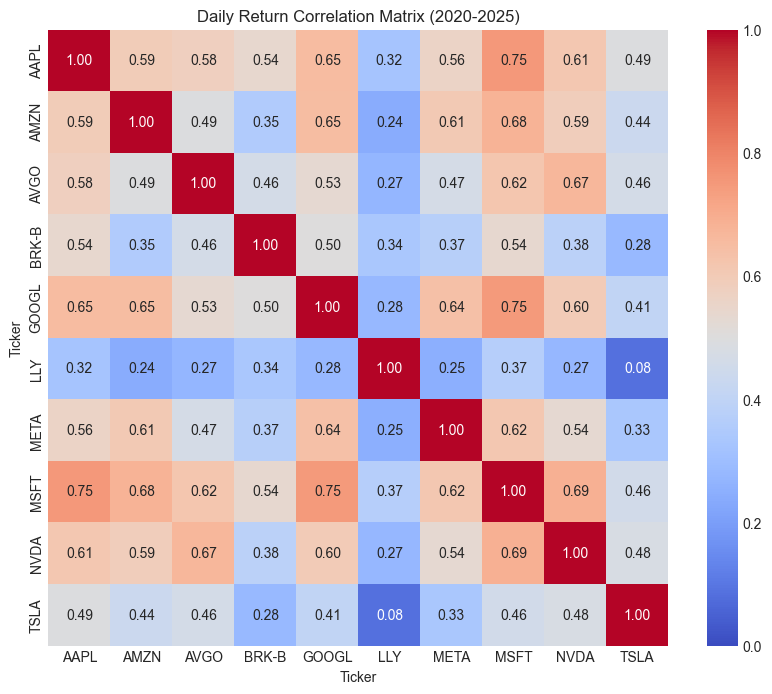

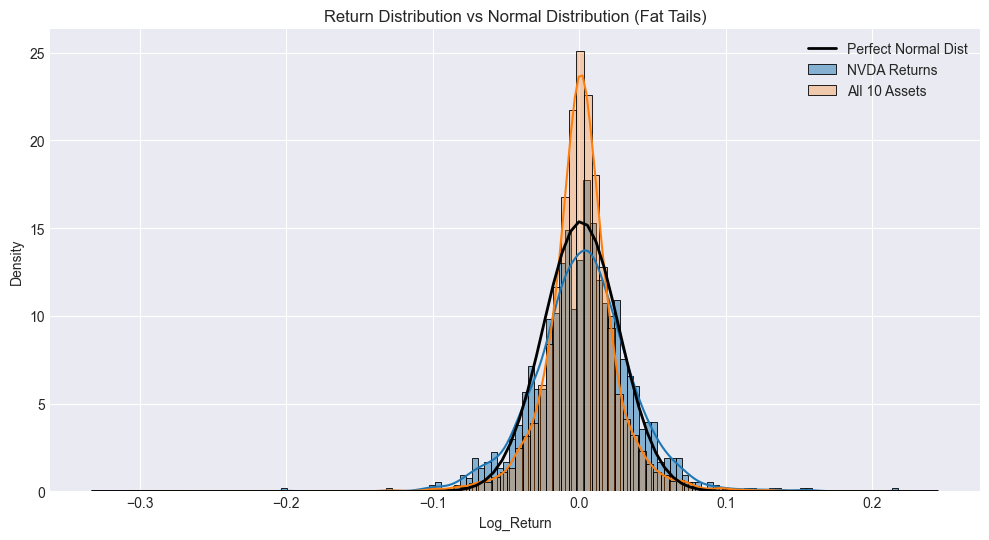

<Figure size 1200x400 with 0 Axes>

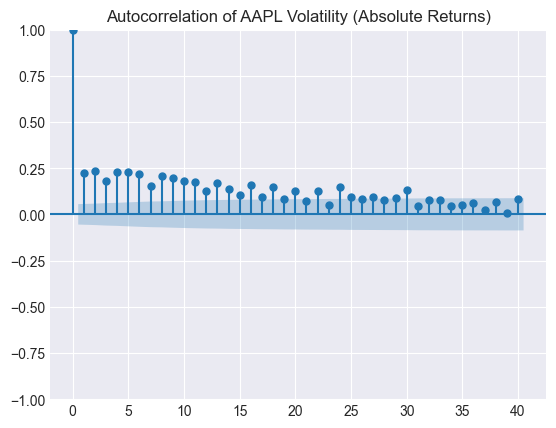

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf


# Set the plotting style 
plt.style.use('seaborn-v0_8-darkgrid')

# Load the data
df = pd.read_csv('../data/processed/cleaned_panel_data.csv')
df['Date'] = pd.to_datetime(df['Date'])

# Calc the log returns
df['Log_Return'] = np.log(df['Close']/df.groupby('Ticker')['Close'].shift(1))
df.dropna(inplace=True)

# Plot 1: Cross-Sectional Correlation Matrix 
returns_wide = df.pivot(index='Date', columns='Ticker', values='Log_Return')
corr_matrix = returns_wide.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=0, vmax=1, fmt=".2f")
plt.title('Daily Return Correlation Matrix (2020-2025)')
plt.show()


# Plot 2: Fat Tails (Return Distribution)
plt.figure(figsize=(12, 6))
# Let's look specifically at NVDA vs the broader set
sns.histplot(df[df['Ticker']=='NVDA']['Log_Return'], bins=100, kde=True, label='NVDA Returns', stat='density')
sns.histplot(df['Log_Return'], bins=100, kde=True, label='All 10 Assets', stat='density', alpha=0.3)

# Plot a perfect normal distribution for comparison
mu, std = df['Log_Return'].mean(), df['Log_Return'].std()
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = np.exp(-((x - mu) ** 2) / (2 * std ** 2)) / (std * np.sqrt(2 * np.pi))
plt.plot(x, p, 'k', linewidth=2, label='Perfect Normal Dist')

plt.title('Return Distribution vs Normal Distribution (Fat Tails)')
plt.legend()
plt.show()

# ==========================================
# Plot 3: Volatility Clustering (Autocorrelation)
# ==========================================
plt.figure(figsize=(12, 4))
# Calculate absolute returns to represent daily volatility
aapl_vol = df[df['Ticker']=='AAPL']['Log_Return'].abs()
plot_acf(aapl_vol, lags=40, title='Autocorrelation of AAPL Volatility (Absolute Returns)')
plt.show()